# RSVP Extended Experiments Notebook
This notebook extends the previous lattice/PDE demo with **more RSVP-style experiments** inspired by the monograph.

Core ideas we operationalize here:
- **Time as an ordering of admissible updates** and coupling ruled by entropy monotonicity (lattice view).
- **Admissibility plateaus**: high-entropy domains become dynamically inert even if scalar availability remains high.
- **Torsion/vorticity as entropy-generating closed relaxation loops**, leading to suppression.
- **Cosmological aging analog**: entropy caps → phase plateaus.
- **Redshift-as-relaxation** toy integral: cumulative loss along a path tied to (Φ,S,χ).

Dependencies: numpy, matplotlib. Qiskit optional.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=4, suppress=True)

## 0. Utilities

In [2]:
def roll(a, s, ax): 
    return np.roll(a, s, axis=ax)

def grad_x(f, dx): 
    return (roll(f, -1, 1) - roll(f, 1, 1)) / (2*dx)

def grad_y(f, dy): 
    return (roll(f, -1, 0) - roll(f, 1, 0)) / (2*dy)

def laplacian(f, dx, dy):
    return ((roll(f,-1,1) - 2*f + roll(f,1,1))/(dx*dx)
          + (roll(f,-1,0) - 2*f + roll(f,1,0))/(dy*dy))

def advect(f, vx, vy, dx, dy):
    fx = np.where(vx >= 0, (f - roll(f,1,1))/dx,
                           (roll(f,-1,1)-f)/dx)
    fy = np.where(vy >= 0, (f - roll(f,1,0))/dy,
                           (roll(f,-1,0)-f)/dy)
    return -(vx*fx + vy*fy)

def div(Fx, Fy, dx, dy):
    return (roll(Fx, -1, 1) - roll(Fx, 1, 1)) / (2.0*dx) +                (roll(Fy, -1, 0) - roll(Fy, 1, 0)) / (2.0*dy)

def normalize_angle(theta):
    return float(theta % (2.0*np.pi))

def plateau_filter(theta_series, strength=0.2):
    out = np.empty_like(theta_series)
    out[0] = theta_series[0]
    for i in range(1, len(theta_series)):
        out[i] = (1.0-strength)*out[i-1] + strength*theta_series[i]
    return out


## 1. Zero-dimensional RSVP toy (Φ, S, χ)
A minimal admissibility-first update rule: entropy and history are monotone; availability is consumed by entropy and saturates. We compare different update schedules to show *path dependence* (same Φ may imply different χ).

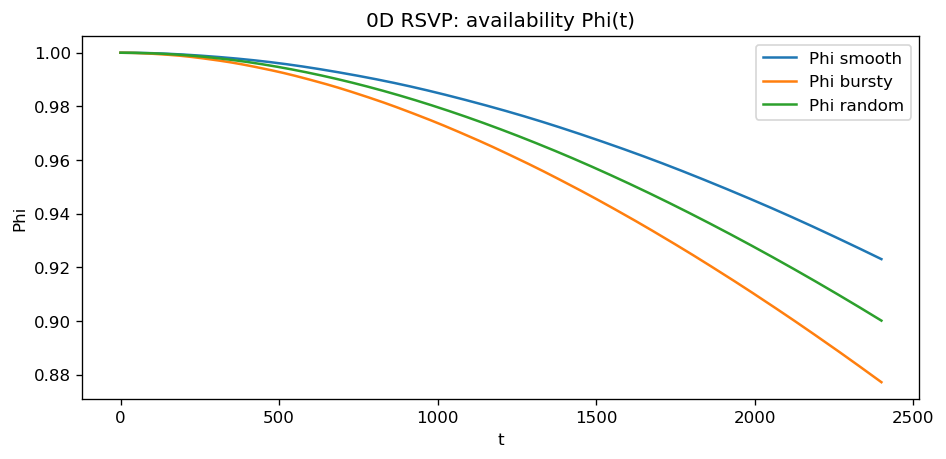

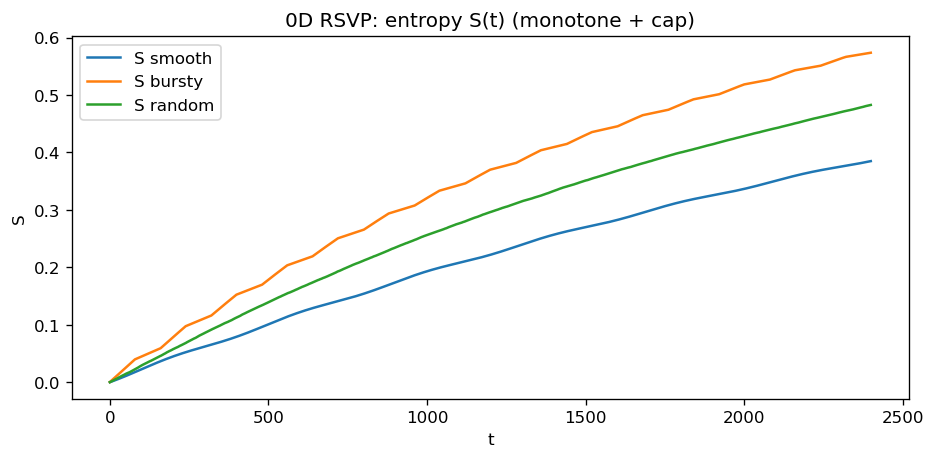

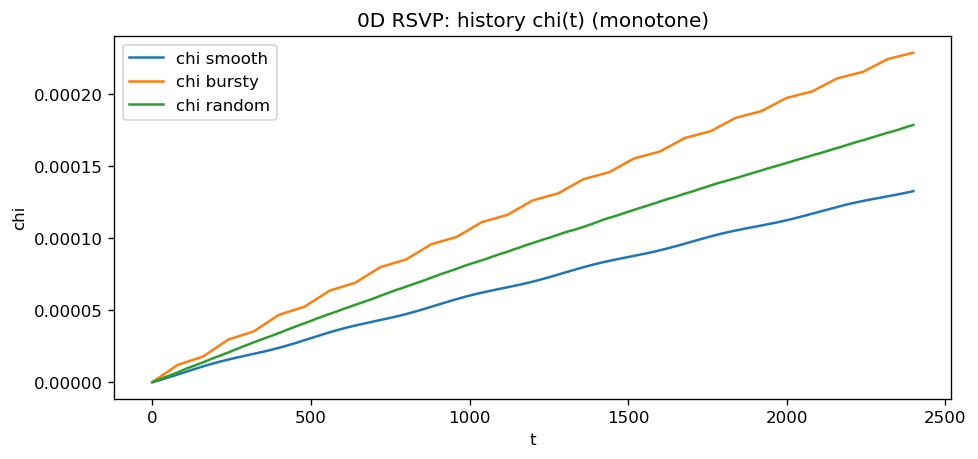

Final values:
smooth: 0.9230745501337342 0.38493072150284013 0.00013257984305581604
bursty: 0.8772068818936917 0.5735423537553204 0.0002286266174260878
random: 0.9001551788181938 0.48267650232978343 0.00017851810114788693


In [3]:

def rsvp0d_run(T=2000, dt=1e-2, seed=0, mode="smooth"):
    rng = np.random.default_rng(seed)
    Phi = 1.0
    S = 0.0
    chi = 0.0

    # knobs
    S_max = 1.0
    k_prod = 0.02
    k_relax = 0.015
    k_chi = 0.03
    k_cap = 5.0

    Phi_hist = np.zeros(T)
    S_hist = np.zeros(T)
    chi_hist = np.zeros(T)

    for t in range(T):
        # "proposal intensity": schedule affects path
        if mode == "smooth":
            drive = 1.0 + 0.2*np.sin(2*np.pi*t/400.0)
        elif mode == "bursty":
            drive = 1.0 + (1.5 if (t//80) % 2 == 0 else 0.2)
        elif mode == "random":
            drive = 0.8 + 1.2*rng.random()
        else:
            drive = 1.0

        # entropy production suppressed as S approaches cap, and by increasing chi
        cap_factor = 1.0 / (1.0 + k_cap*(S/S_max)**2)
        hist_factor = 1.0 / (1.0 + 2.0*chi)

        dS = dt * (k_prod * drive * cap_factor * hist_factor)
        S_new = min(S + dS, S_max)  # monotone + cap

        # chi accumulates when entropy increases, with extra weight when nearing saturation
        dchi = dt * (k_chi * (S_new - S) * (1.0 + 3.0*(S/S_max)**2))
        chi_new = chi + dchi  # monotone

        # Phi consumed by entropy pressure and history
        dPhi = dt * (-k_relax * (S_new + 0.5*chi_new))
        Phi_new = max(Phi + dPhi, 1e-6)

        Phi, S, chi = Phi_new, S_new, chi_new
        Phi_hist[t], S_hist[t], chi_hist[t] = Phi, S, chi

    return Phi_hist, S_hist, chi_hist

T=2400
Phi_a, S_a, chi_a = rsvp0d_run(T=T, mode="smooth")
Phi_b, S_b, chi_b = rsvp0d_run(T=T, mode="bursty")
Phi_c, S_c, chi_c = rsvp0d_run(T=T, mode="random")

t = np.arange(T)

fig = plt.figure(figsize=(9,4))
plt.plot(t, Phi_a, label="Phi smooth")
plt.plot(t, Phi_b, label="Phi bursty")
plt.plot(t, Phi_c, label="Phi random")
plt.xlabel("t")
plt.ylabel("Phi")
plt.title("0D RSVP: availability Phi(t)")
plt.legend()
plt.show()

fig = plt.figure(figsize=(9,4))
plt.plot(t, S_a, label="S smooth")
plt.plot(t, S_b, label="S bursty")
plt.plot(t, S_c, label="S random")
plt.xlabel("t")
plt.ylabel("S")
plt.title("0D RSVP: entropy S(t) (monotone + cap)")
plt.legend()
plt.show()

fig = plt.figure(figsize=(9,4))
plt.plot(t, chi_a, label="chi smooth")
plt.plot(t, chi_b, label="chi bursty")
plt.plot(t, chi_c, label="chi random")
plt.xlabel("t")
plt.ylabel("chi")
plt.title("0D RSVP: history chi(t) (monotone)")
plt.legend()
plt.show()

print("Final values:")
print("smooth:", Phi_a[-1], S_a[-1], chi_a[-1])
print("bursty:", Phi_b[-1], S_b[-1], chi_b[-1])
print("random:", Phi_c[-1], S_c[-1], chi_c[-1])


## 2. Lattice RSVP with an admissibility gate
We implement a 1D ring lattice where **Φ exchange is proposed by gradients** but **accepted only if it does not decrease entropy** and if both sites are below a saturation threshold. This directly illustrates: low-S regions act as sinks only until they saturate, and then the lattice fragments into **admissibility plateaus**.

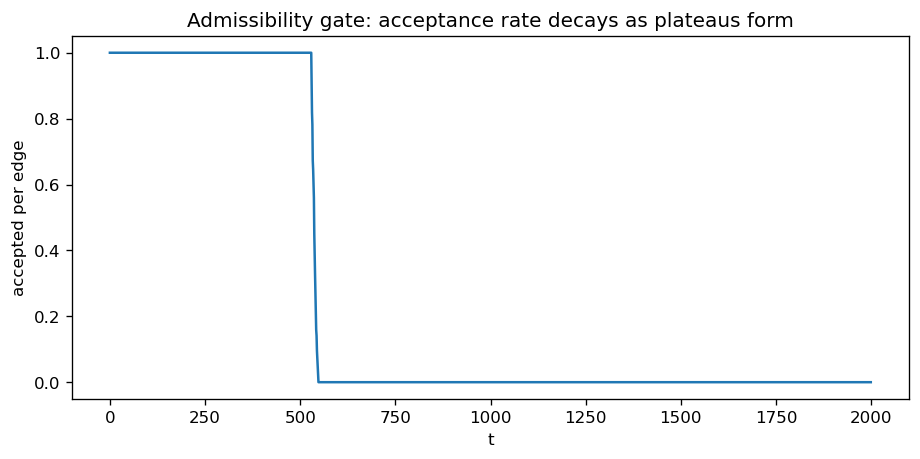

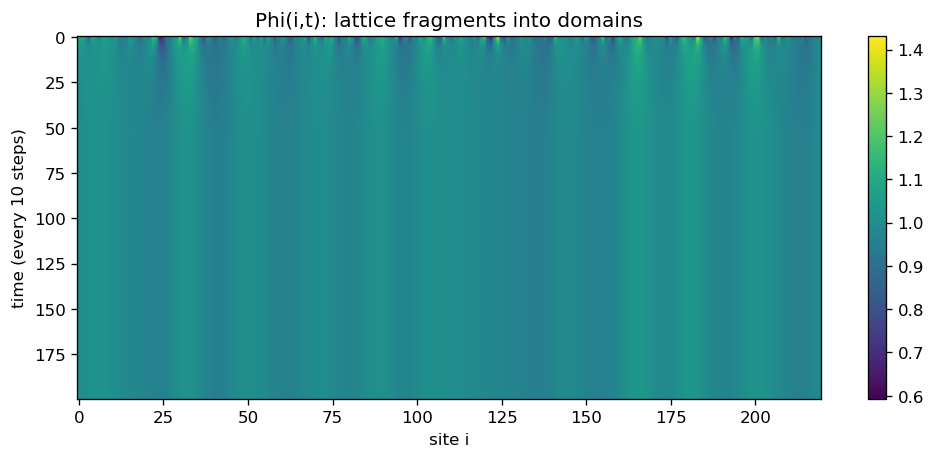

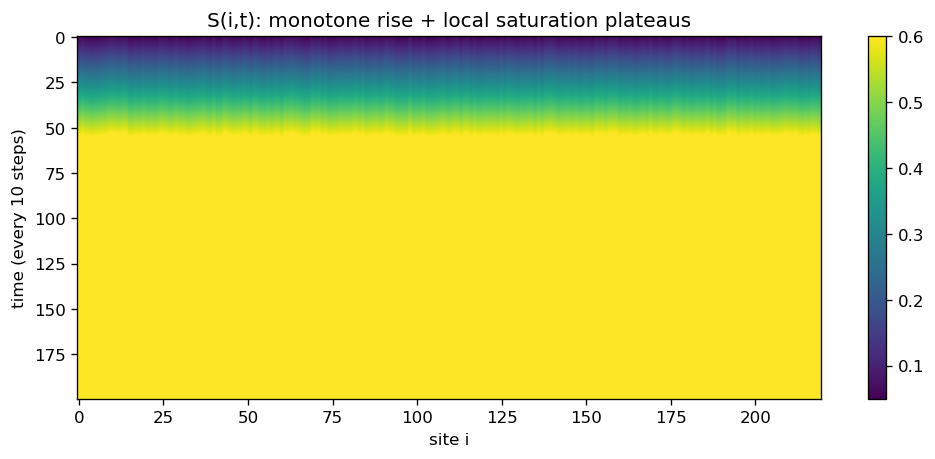

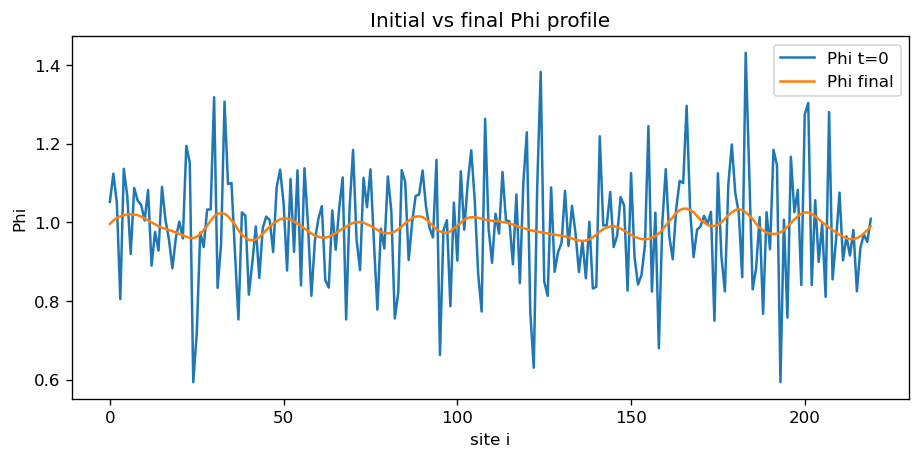

In [4]:

def lattice1d_run(N=200, T=2500, seed=0):
    rng = np.random.default_rng(seed)
    # fields
    Phi = 1.0 + 0.15*rng.normal(size=N)
    Phi = np.clip(Phi, 0.05, None)
    S = 0.05 + 0.02*rng.random(size=N)
    chi = np.zeros(N)

    # parameters
    S_max = 0.6
    dt = 1.0
    k_prop = 0.03          # proposal strength
    k_prod0 = 1e-3         # baseline entropy production
    k_prod_flow = 1e-2     # production per accepted exchange (models irreversibility cost)
    k_chi = 1e-2
    k_hist_suppress = 1.0  # chi suppresses future production / acceptance

    # record
    Phi_hist = np.zeros((T, N))
    S_hist = np.zeros((T, N))
    accept_rate = np.zeros(T)

    for t in range(T):
        Phi_hist[t] = Phi
        S_hist[t] = S

        # baseline monotone entropy production (aging)
        S = np.minimum(S + k_prod0*(1.0/(1.0 + k_hist_suppress*chi)), S_max)

        accepted = 0
        # sweep edges (i -> i+1)
        for i in range(N):
            j = (i+1) % N

            # propose exchange from high Phi -> low Phi
            d = Phi[i] - Phi[j]
            flow = k_prop * d

            # admissibility: do not allow if either site saturated, or if history blocks it
            if S[i] >= S_max or S[j] >= S_max:
                continue
            if (1.0/(1.0 + chi[i] + chi[j])) < 0.3:
                continue

            # exchange amount
            delta = 0.5*flow
            if delta == 0:
                continue

            # compute entropy increment cost (always nonnegative)
            cost_i = k_prod_flow * (delta*delta)
            cost_j = k_prod_flow * (delta*delta)

            # accept if costs keep entropy monotone and below cap
            if (S[i] + cost_i <= S_max) and (S[j] + cost_j <= S_max):
                # update Phi
                Phi[i] -= delta
                Phi[j] += delta
                # update entropy + history
                S[i] = min(S[i] + cost_i, S_max)
                S[j] = min(S[j] + cost_j, S_max)
                chi[i] += k_chi * cost_i
                chi[j] += k_chi * cost_j
                accepted += 1

        accept_rate[t] = accepted / N

    return Phi_hist, S_hist, accept_rate

Phi_hist, S_hist, acc = lattice1d_run(N=220, T=2000, seed=1)

fig = plt.figure(figsize=(9,4))
plt.plot(acc)
plt.xlabel("t")
plt.ylabel("accepted per edge")
plt.title("Admissibility gate: acceptance rate decays as plateaus form")
plt.show()

# show heatmaps for Phi and S
fig = plt.figure(figsize=(10,4))
plt.imshow(Phi_hist[::10], aspect="auto")
plt.xlabel("site i")
plt.ylabel("time (every 10 steps)")
plt.title("Phi(i,t): lattice fragments into domains")
plt.colorbar()
plt.show()

fig = plt.figure(figsize=(10,4))
plt.imshow(S_hist[::10], aspect="auto")
plt.xlabel("site i")
plt.ylabel("time (every 10 steps)")
plt.title("S(i,t): monotone rise + local saturation plateaus")
plt.colorbar()
plt.show()

# final profiles
fig = plt.figure(figsize=(9,4))
plt.plot(Phi_hist[0], label="Phi t=0")
plt.plot(Phi_hist[-1], label="Phi final")
plt.xlabel("site i")
plt.ylabel("Phi")
plt.title("Initial vs final Phi profile")
plt.legend()
plt.show()


## 3. 2D torsion-driven PDE lattice (extended)
We reuse the earlier style: torsion-driven flow with vorticity penalty; entropy production suppressed by torsion; history χ accumulates; entropy cap produces phase plateaus. Here we add **parameter sweeps** (torsion suppression strength and entropy cap) and compare plateau statistics.

In [6]:
# A compact 2D simulator (self-contained for this notebook)
import numpy as np

def curl_z(vx, vy, dx, dy):
    return grad_x(vy, dx) - grad_y(vx, dy)

def perp_grad(f, dx, dy):
    return -grad_y(f, dy), grad_x(f, dx)

def step_flow(
    vx, vy, Phi, S, dx, dy, dt,
    lam=0.6, gamma=0.9, nu=1.4, kv=2e-3,
    omega_max=20.0, v_max=5.0
):
    # vorticity (torsion proxy) with saturation before squaring
    ω = curl_z(vx, vy, dx, dy)
    ω = np.nan_to_num(ω, nan=0.0, posinf=omega_max, neginf=-omega_max)
    ω = np.clip(ω, -omega_max, omega_max)

    # torsion drive (perpendicular gradient of ω)
    tx, ty = perp_grad(ω, dx, dy)

    # vorticity penalty computed from bounded ω^2
    ω2 = ω * ω
    pen_x = grad_x(ω2, dx)
    pen_y = grad_y(ω2, dy)

    # self-advection
    advvx = advect(vx, vx, vy, dx, dy)
    advvy = advect(vy, vx, vy, dx, dy)

    dvx = advvx + lam*tx - gamma*pen_x - nu*vx + kv*laplacian(vx, dx, dy)
    dvy = advvy + lam*ty - gamma*pen_y - nu*vy + kv*laplacian(vy, dx, dy)

    vx_new = vx + dt*dvx
    vy_new = vy + dt*dvy

    # clamp velocities (crude CFL guard)
    vx_new = np.nan_to_num(vx_new, nan=0.0, posinf=v_max, neginf=-v_max)
    vy_new = np.nan_to_num(vy_new, nan=0.0, posinf=v_max, neginf=-v_max)
    vx_new = np.clip(vx_new, -v_max, v_max)
    vy_new = np.clip(vy_new, -v_max, v_max)

    return vx_new, vy_new

def torsion_suppression(vx, vy, dx, dy, alpha_omega=2.0, omega_max=20.0):
    ω = curl_z(vx, vy, dx, dy)
    ω = np.nan_to_num(ω, nan=0.0, posinf=omega_max, neginf=-omega_max)
    ω = np.clip(ω, -omega_max, omega_max)
    Gamma = 1.0 / (1.0 + alpha_omega*(ω*ω))
    return Gamma, ω

def equilibrium_score(TA, TB, Phi, chi, k=0.15, eps=1e-12):
    Phi_safe = np.maximum(Phi, eps)
    base = (TA + TB) / (2.0 * Phi_safe)
    return base / (1.0 + k*chi)

def theta_from_field(Es):
    Es_bar = float(np.nan_to_num(Es, nan=0.0).mean())
    frac = Es_bar % 1.0
    return float(2.0*np.pi*frac), Es_bar

def simulate_2d(
    seed=0, steps=2500, nx=96, ny=96, dt=2e-4,
    S_max=0.6, alpha_omega=2.0,
    omega_max=20.0, gradT_max=50.0, v_max=5.0
):
    rng = np.random.default_rng(seed)
    Lx = Ly = 1.0
    dx = Lx/nx
    dy = Ly/ny
    T_env = 300.0

    # initial fields
    TA = T_env + 3.0*rng.normal(size=(ny, nx))
    TB = T_env + 3.0*rng.normal(size=(ny, nx))
    Phi = np.maximum(1.0 + 0.05*rng.normal(size=(ny, nx)), 1e-6)
    S   = np.maximum(0.05 + 0.02*rng.random(size=(ny, nx)), 0.0)
    chi = np.zeros((ny, nx))

    # initial vortex-like drift
    y = np.linspace(0, 1, ny, endpoint=False)
    x = np.linspace(0, 1, nx, endpoint=False)
    X, Y = np.meshgrid(x, y)
    vx = 0.2*(Y - 0.5)
    vy = -0.2*(X - 0.5)

    # params
    kT   = 8e-4
    kPhi = 6e-4
    kS   = 8e-4
    alphaA = 0.6
    alphaB = 0.5
    lamAB  = 1.2
    gammaPhi = 0.8
    etaPhi   = 0.35
    mu = 0.6
    chi_a = 0.8
    chi_b = 0.01
    chi_k = 2e-4

    theta = np.zeros(steps + 1)

    def soft_cap_sink(Sfield, k_cap=3.0, power=1.0):
        Smax = max(float(S_max), 1e-12)
        Spos = np.maximum(Sfield, 0.0)
        ratio = Spos / Smax
        return k_cap * Spos * (ratio**power)

    for n in range(steps + 1):
        Es = equilibrium_score(TA, TB, Phi, chi, k=0.15)
        th, _ = theta_from_field(Es)
        theta[n] = th

        if n == steps:
            break

        # flow step (stabilized)
        vx, vy = step_flow(
            vx, vy, Phi, S, dx, dy, dt,
            lam=0.6, gamma=0.9, nu=1.4, kv=2e-3,
            omega_max=omega_max, v_max=v_max
        )

        # temperatures
        TA = TA + dt*(advect(TA, vx, vy, dx, dy) + kT*laplacian(TA, dx, dy)
                      - alphaA*(TA - T_env) + lamAB*(TB - TA))
        TB = TB + dt*(advect(TB, vx, vy, dx, dy) + kT*laplacian(TB, dx, dy)
                      - alphaB*(TB - T_env) + lamAB*(TA - TB))

        # bound temps to avoid explosive gradients
        TA = np.nan_to_num(TA, nan=T_env, posinf=1e4, neginf=1.0)
        TB = np.nan_to_num(TB, nan=T_env, posinf=1e4, neginf=1.0)
        TA = np.clip(TA, 1.0, 1e4)
        TB = np.clip(TB, 1.0, 1e4)

        # entropy production (torsion-suppressed, stabilized)
        Gamma, ω = torsion_suppression(vx, vy, dx, dy, alpha_omega=alpha_omega, omega_max=omega_max)

        dTx = grad_x(TA - TB, dx)
        dTy = grad_y(TA - TB, dy)

        dTx = np.nan_to_num(dTx, nan=0.0, posinf=gradT_max, neginf=-gradT_max)
        dTy = np.nan_to_num(dTy, nan=0.0, posinf=gradT_max, neginf=-gradT_max)
        dTx = np.clip(dTx, -gradT_max, gradT_max)
        dTy = np.clip(dTy, -gradT_max, gradT_max)

        gradT2 = dTx*dTx + dTy*dTy
        prod = (0.01 + 0.02*gradT2) * Gamma

        # cap spikes (keeps S update tame)
        prod = np.nan_to_num(prod, nan=0.0, posinf=1.0, neginf=0.0)
        prod = np.clip(prod, 0.0, 1.0)

        dS = (advect(S, vx, vy, dx, dy) + kS*laplacian(S, dx, dy) + prod
              - mu*Phi*S - soft_cap_sink(S))
        S = S + dt*dS
        S = np.nan_to_num(S, nan=0.0, posinf=S_max, neginf=0.0)
        S = np.clip(S, 0.0, S_max)

        # history
        dchi = advect(chi, vx, vy, dx, dy) + chi_a*S - chi_b*chi + chi_k*laplacian(chi, dx, dy)
        chi = chi + dt*dchi
        chi = np.nan_to_num(chi, nan=0.0, posinf=1e6, neginf=0.0)
        chi = np.maximum(chi, 0.0)

        # Phi transport + relax (history slows)
        Phi = Phi + dt*(-div(Phi*vx, Phi*vy, dx, dy))
        Phi = Phi + dt*(kPhi*laplacian(Phi, dx, dy) - gammaPhi*(Phi - 1.0)/(1.0 + chi) - etaPhi*S)
        Phi = np.nan_to_num(Phi, nan=1.0, posinf=10.0, neginf=1e-6)
        Phi = np.maximum(Phi, 1e-6)

    # plateau metric (phase plateaus via entropy caps)
    dtheta = np.abs(np.diff(theta, prepend=theta[0]))
    is_flat = (dtheta < 1e-3).astype(float)
    window = 50
    flat_score = np.convolve(is_flat, np.ones(window)/window, mode="same")
    plateau_fraction = float((flat_score > 0.9).mean())

    return dict(theta=theta, plateau_fraction=plateau_fraction)

def sweep(alpha_list=(0.5, 1.0, 2.0, 4.0), caps=(0.4, 0.6, 0.8), seed=2):
    rows = []
    for a in alpha_list:
        for cap in caps:
            out = simulate_2d(seed=seed, steps=1800, S_max=cap, alpha_omega=a)
            rows.append((a, cap, out["plateau_fraction"]))
    return rows

rows = sweep()
rows


[(0.5, 0.4, 0.0),
 (0.5, 0.6, 0.0),
 (0.5, 0.8, 0.0),
 (1.0, 0.4, 0.0),
 (1.0, 0.6, 0.0),
 (1.0, 0.8, 0.0),
 (2.0, 0.4, 0.0),
 (2.0, 0.6, 0.0),
 (2.0, 0.8, 0.0),
 (4.0, 0.4, 0.0),
 (4.0, 0.6, 0.0),
 (4.0, 0.8, 0.0)]

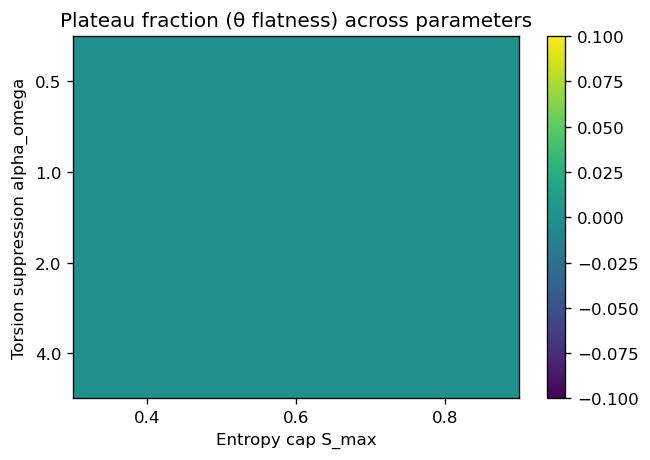

In [7]:

# visualize sweep
alphas = sorted(set(r[0] for r in rows))
caps = sorted(set(r[1] for r in rows))
M = np.zeros((len(alphas), len(caps)))
for a, cap, pf in rows:
    M[alphas.index(a), caps.index(cap)] = pf

fig = plt.figure(figsize=(6,4))
plt.imshow(M, aspect="auto")
plt.xticks(range(len(caps)), [str(c) for c in caps])
plt.yticks(range(len(alphas)), [str(a) for a in alphas])
plt.xlabel("Entropy cap S_max")
plt.ylabel("Torsion suppression alpha_omega")
plt.title("Plateau fraction (θ flatness) across parameters")
plt.colorbar()
plt.show()


## 4. Toy redshift-as-relaxation path integral
RSVP frames redshift as **cumulative, monotone loss** tied to scalar availability and entropy gradients along propagation. Here we build a **toy line-of-sight integral** where a photon’s energy decays with a local rate κ(x) derived from (Φ,S,χ).

We do *not* claim this is the final RSVP redshift law—this is an experiment scaffold.

young toy z = 0.022711147544589805 tau = 0.022457088882470715
aged_plateaus toy z = 0.04858235544471179 tau = 0.047439114240655035
structured toy z = 0.028035644958583017 tau = 0.02764984051606602


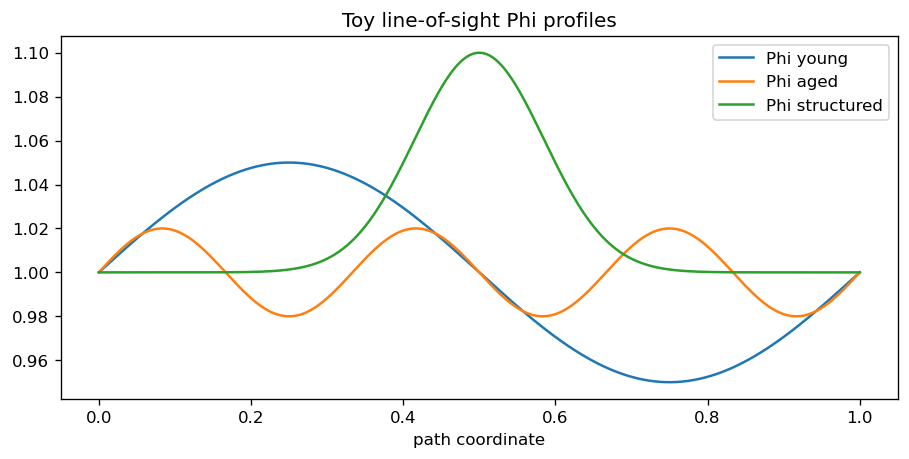

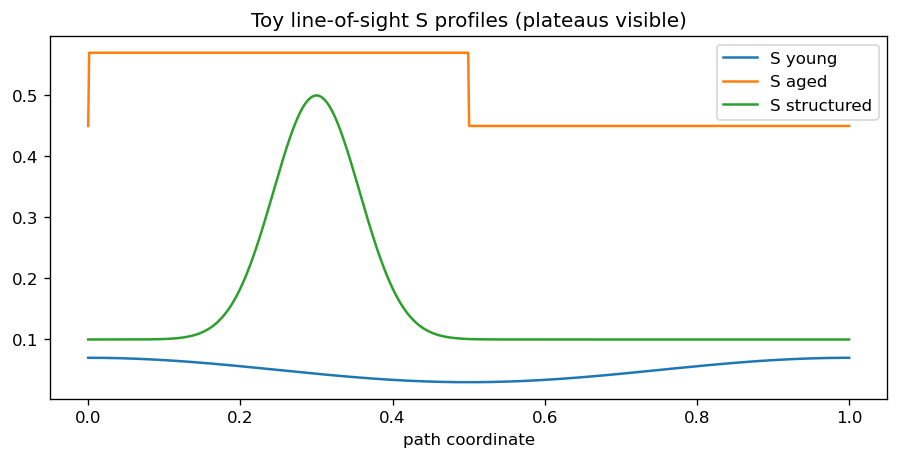

In [8]:

def toy_redshift_integral(Phi, S, chi, ds=1.0, k0=0.01, aS=2.0, aChi=1.0, eps=1e-9):
    # local loss rate; higher S/chi => stronger irreversible drain; higher Phi => lower drain
    kappa = k0 * (1.0 + aS*S + aChi*chi) / (Phi + eps)
    # Energy obeys dE/ds = -kappa(s) E => log(E0/E) = ∫ kappa ds
    tau = np.sum(kappa) * ds
    z = np.exp(tau) - 1.0
    return float(z), float(tau)

# Build a few synthetic "universe lines"
x = np.linspace(0,1,800)

# young: low S, low chi
Phi_y = 1.0 + 0.05*np.sin(2*np.pi*x)
S_y   = 0.05 + 0.02*np.cos(2*np.pi*x)
chi_y = 0.02*np.ones_like(x)

# aged: higher S/chi with plateaus
Phi_a = 1.0 + 0.02*np.sin(6*np.pi*x)
S_a   = 0.45 + 0.12*(np.sin(2*np.pi*x)>0).astype(float)  # plateau blocks
chi_a = 0.25 + 0.20*(np.sin(2*np.pi*x)>0).astype(float)

# structured: gradients
Phi_s = 1.0 + 0.10*np.exp(-((x-0.5)/0.12)**2)
S_s   = 0.10 + 0.40*np.exp(-((x-0.3)/0.08)**2)
chi_s = 0.05 + 0.25*np.exp(-((x-0.7)/0.10)**2)

for name, Phi, S, chi in [
    ("young", Phi_y, S_y, chi_y),
    ("aged_plateaus", Phi_a, S_a, chi_a),
    ("structured", Phi_s, S_s, chi_s)
]:
    z, tau = toy_redshift_integral(Phi, S, chi, ds=(x[1]-x[0]), k0=0.02)
    print(name, "toy z =", z, "tau =", tau)

fig = plt.figure(figsize=(9,4))
plt.plot(x, Phi_y, label="Phi young")
plt.plot(x, Phi_a, label="Phi aged")
plt.plot(x, Phi_s, label="Phi structured")
plt.xlabel("path coordinate")
plt.title("Toy line-of-sight Phi profiles")
plt.legend()
plt.show()

fig = plt.figure(figsize=(9,4))
plt.plot(x, S_y, label="S young")
plt.plot(x, S_a, label="S aged")
plt.plot(x, S_s, label="S structured")
plt.xlabel("path coordinate")
plt.title("Toy line-of-sight S profiles (plateaus visible)")
plt.legend()
plt.show()


## 5. Phase plateaus from entropy caps (scalar→phase)
We generate θ(t) from an equilibrium score and then apply an explicit plateau filter to mimic cap-driven insensitivity. We compare raw θ vs plateau-filtered θ and compute flatness.

plateau fraction raw: 0.0
plateau fraction filtered: 0.0


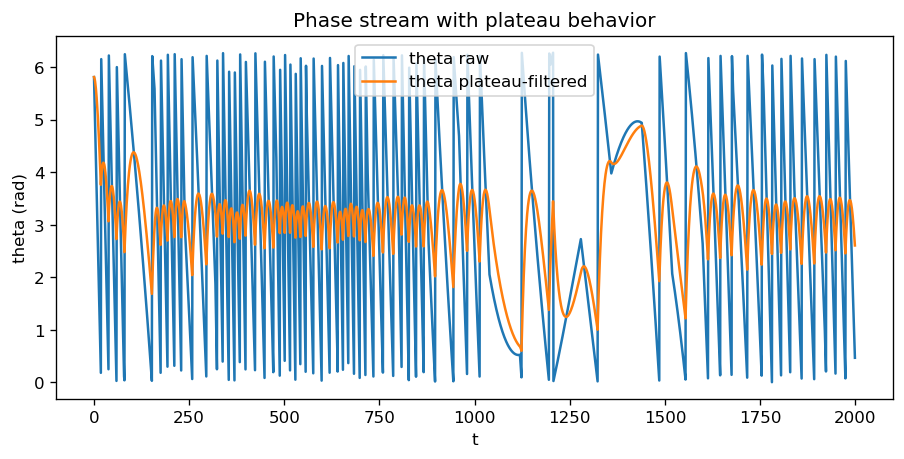

In [9]:

# Use a 0D-derived equilibrium score for a phase stream
Phi, S, chi = rsvp0d_run(T=2000, mode="bursty")
# define a toy equilibrium score and theta
Es = (300.0 + 5.0*np.sin(np.linspace(0,10,2000))) / (1.0 + 0.5*S + 0.5*chi)
theta_raw = (Es % 1.0) * 2.0*np.pi
theta_plateau = plateau_filter(theta_raw, strength=0.05)

def plateau_fraction(theta, thr=1e-3, window=40):
    d = np.abs(np.diff(theta, prepend=theta[0]))
    is_flat = (d < thr).astype(float)
    score = np.convolve(is_flat, np.ones(window)/window, mode="same")
    return float((score > 0.9).mean())

print("plateau fraction raw:", plateau_fraction(theta_raw))
print("plateau fraction filtered:", plateau_fraction(theta_plateau))

fig = plt.figure(figsize=(9,4))
plt.plot(theta_raw, label="theta raw")
plt.plot(theta_plateau, label="theta plateau-filtered")
plt.xlabel("t")
plt.ylabel("theta (rad)")
plt.title("Phase stream with plateau behavior")
plt.legend()
plt.show()


## 6. Optional quantum hook: scalar θ on RZ, vector proxy on RX/RY
If Qiskit is installed, build a GHZ-like circuit where θ controls RZ and a vector proxy (from ∇S) controls RX/RY.

In [10]:

try:
    from qiskit import QuantumCircuit
    qiskit_ok = True
except Exception as e:
    qiskit_ok = False
    print("Qiskit not available:", e)

def build_hybrid_circuit(theta_z, theta_x, theta_y):
    qc = QuantumCircuit(3)
    qc.h(2)
    qc.cx(2,0); qc.cx(2,1)
    qc.rz(theta_z, 0); qc.rz(theta_z, 1)
    qc.rx(theta_x, 0)
    qc.ry(theta_y, 1)
    qc.barrier()
    return qc

if qiskit_ok:
    # vector proxy: use a synthetic gradient signal
    gx = float(np.mean(np.gradient(S_a)))  # from toy line
    gy = float(np.mean(np.gradient(chi_a)))
    theta_z = float(theta_plateau[-1])
    theta_x = float(np.pi * gx)
    theta_y = float(np.pi * gy)

    qc = build_hybrid_circuit(theta_z, theta_x, theta_y)
    print("Angles:")
    print("RZ:", theta_z, "RX:", theta_x, "RY:", theta_y)
    print(qc.draw(output="text"))


Qiskit not available: cannot import name 'Self' from 'typing_extensions' (C:\Users\Mechachleopteryx\AppData\Roaming\Python\Python38\site-packages\typing_extensions.py)


## 7. What to try next
- Replace the toy redshift κ(x) with a candidate RSVP propagation law and test invariants.
- Couple the 1D lattice gate to an explicit vector field update (dominant admissible direction) and visualize filaments.
- Add a second history index (χ_torsion vs χ_smooth) to test hysteresis with equal S.
- Run ensembles and look for robust plateau statistics under discretization changes.
